In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/anonymized_marks.csv')

print("Data loaded successfully. Displaying the first 5 rows:")
display(df.head())

Data loaded successfully. Displaying the first 5 rows:


,Student,Marks
0,Student1,14.5
1,Student2,1.0
2,Student3,5.0
3,Student4,5.0
4,Student5,13.0


In [2]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Description:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  59 non-null     object 
 1   Marks    59 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.1+ KB

DataFrame Description:


,Marks
count,59.000000
mean,7.881356
std,5.032942
min,0.000000
25%,4.000000
50%,6.000000
75%,12.250000
max,17.500000


In [6]:
print(f"Standard Deviation of Marks: {df['Marks'].std():.2f}")
print(f"Variance of Marks: {df['Marks'].var():.2f}")

Standard Deviation of Marks: 5.03
Variance of Marks: 25.33


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Reshape the 'Marks' column to a 2D array as required by MinMaxScaler
marks_reshaped = df['Marks'].values.reshape(-1, 1)

# Fit and transform the data
df['Normalized_Marks'] = scaler.fit_transform(marks_reshaped)

print("Marks data normalized using Min-Max Scaling. Displaying first 5 rows with new column:")
display(df.head())

Marks data normalized using Min-Max Scaling. Displaying first 5 rows with new column:


,Student,Marks,Normalized_Marks
0,Student1,14.5,0.828571
1,Student2,1.0,0.057143
2,Student3,5.0,0.285714
3,Student4,5.0,0.285714
4,Student5,13.0,0.742857


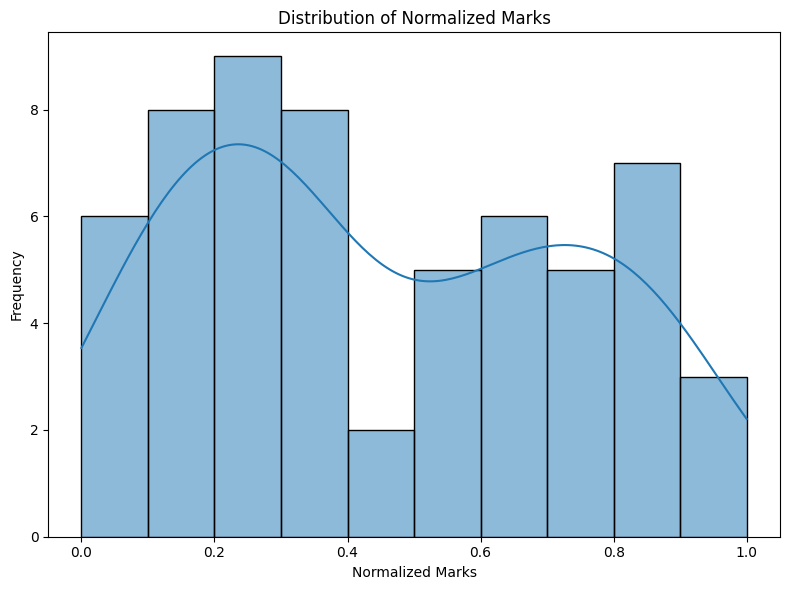

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Normalized_Marks'], kde=True, bins=10)
plt.title('Distribution of Normalized Marks')
plt.xlabel('Normalized Marks')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

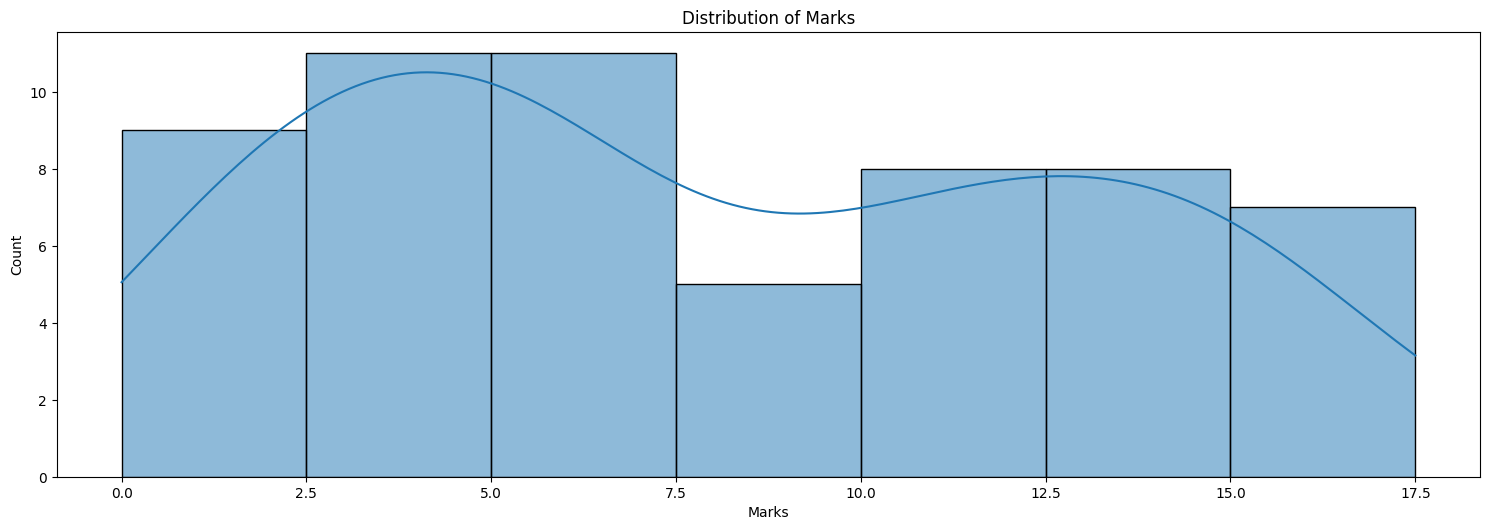

In [3]:
numeric_cols = df.select_dtypes(include=['number']).columns

if not numeric_cols.empty:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numeric_cols):
        plt.subplot(2, (len(numeric_cols) + 1) // 2, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for histogram visualization.")

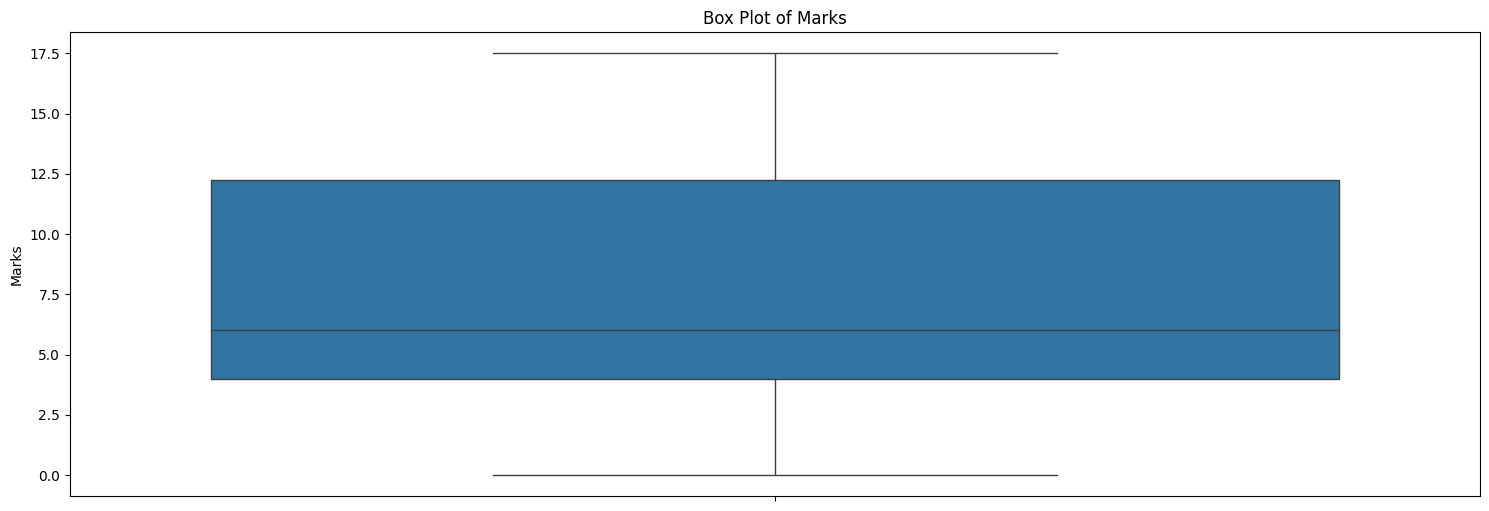

In [4]:
if not numeric_cols.empty:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numeric_cols):
        plt.subplot(2, (len(numeric_cols) + 1) // 2, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for box plot visualization.")